<a href="https://colab.research.google.com/github/Pranayshukla0610/Convolutional_Neural_Network-CNN-/blob/main/MNIST_CNN_Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
a = np.array([1,2,3])
print(a)

[1 2 3]


In [4]:
(X_train,y_train), (X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


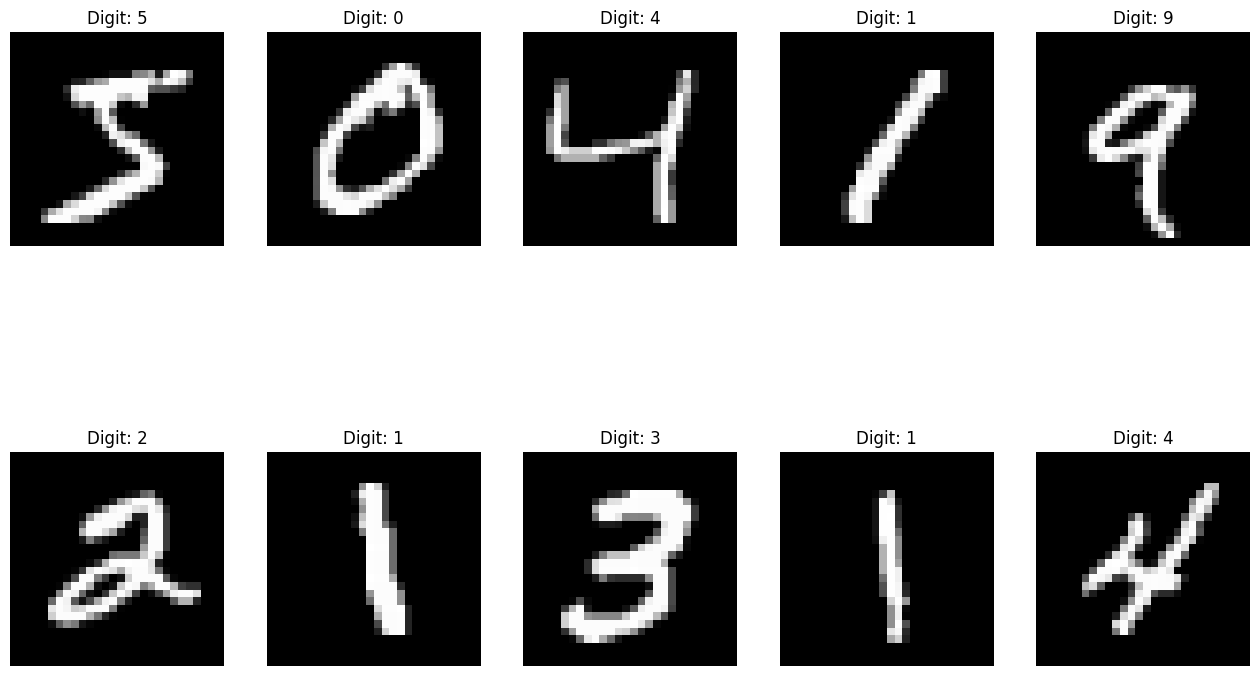

In [6]:
plt.figure(figsize=(16,10))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i],cmap='gray')
  plt.title(f"Digit: {y_train[i]}")
  plt.axis('off')

plt.show()

In [7]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


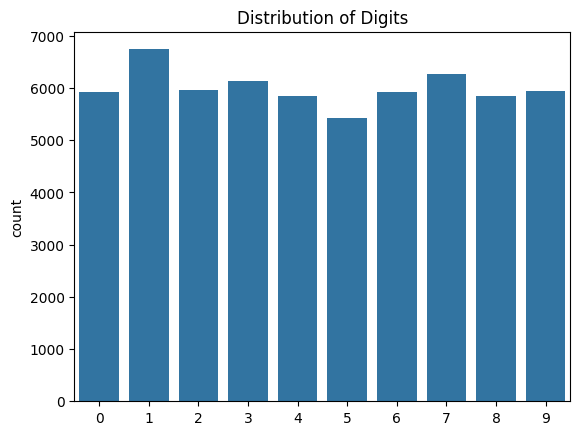

In [8]:
sns.countplot(x=y_train)
plt.title('Distribution of Digits')
plt.show()

In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)

(60000, 28, 28, 1)


In [11]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [12]:
model = Sequential()

model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(10,activation='softmax'))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,162 (879.54 KB)

 Trainable params: 225,098 (879.29 KB)

 Non-trainable params: 64 (256.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.9407 - loss: 0.1925 - val_accuracy: 0.9830 - val_loss: 0.0584
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.9803 - loss: 0.0640 - val_accuracy: 0.9877 - val_loss: 0.0428
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 75ms/step - accuracy: 0.9856 - loss: 0.0479 - val_accuracy: 0.9847 - val_loss: 0.0537
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9898 - val_loss: 0.0368
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.9904 - loss: 0.0316 - val_accuracy: 0.9905 - val_loss: 0.0396
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.9921 - loss: 0.0236 - val_accuracy: 0.9891 - val_loss: 0.0477
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.9928 - loss: 0.0226 - val_accuracy: 0.9899 - val_loss: 0.0428
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.9931 - loss: 0.0207 - 

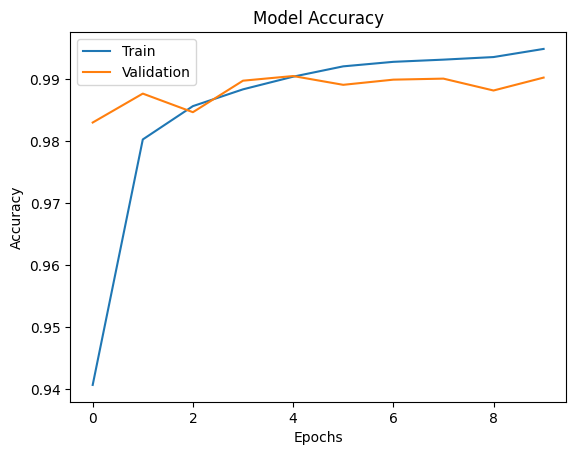

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])
plt.show()

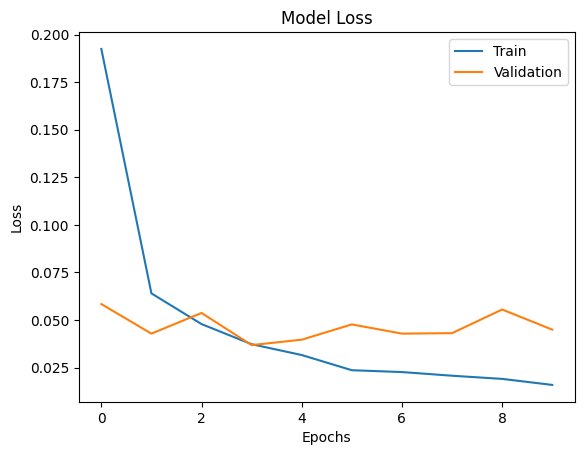

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])
plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9901 - loss: 0.0372
Test Accuracy: 0.9901000261306763


In [19]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [20]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test,axis=1)

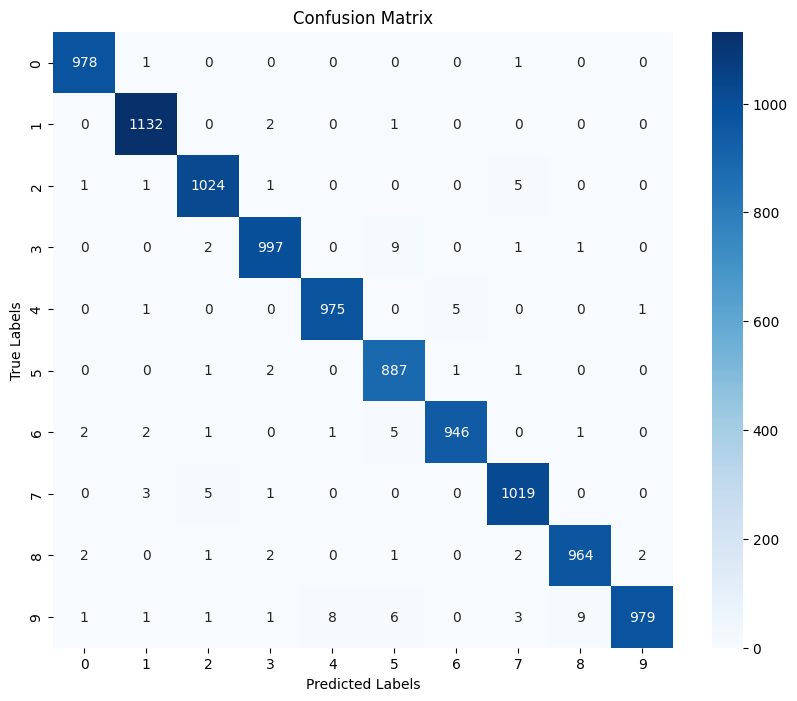

In [21]:
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [22]:
print(classification_report(
    true_labels,
    predicted_labels
))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



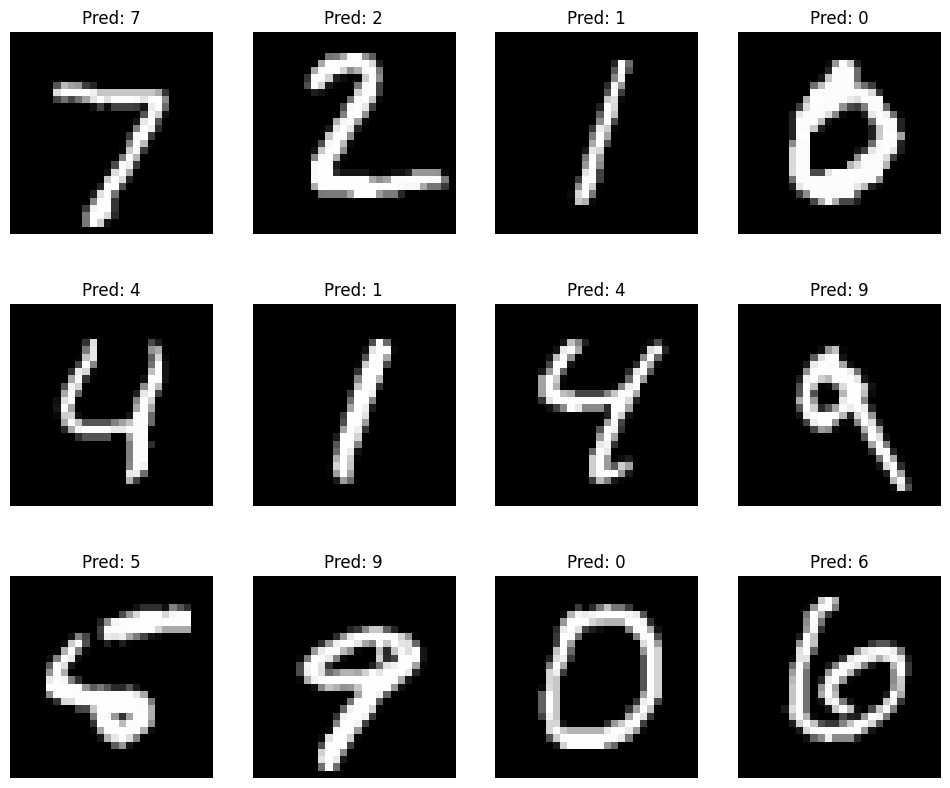

In [23]:
plt.figure(figsize=(12,10))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Pred: {predicted_labels[i]}"
    )

    plt.axis('off')

plt.show()

In [24]:
model.save("mnist_cnn_model.h5")

In [25]:
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_cnn_model.h5")

In [26]:
from google.colab import files
uploaded = files.upload()

Saving 1-Number-PNG-Picture.png to 1-Number-PNG-Picture.png
